# 01 — Baseline ASR Evaluation: Whisper vs Wav2Vec 2.0

Notebook ini mengevaluasi dua model ASR pre-trained (tanpa fine-tuning) pada satu file rekaman kuliah Filkom UB.

**Models yang dievaluasi:**
- OpenAI Whisper (`large-v3` dan `medium`)
- Wav2Vec 2.0 XLSR-53 Indonesian

**Metrik:**
- Word Error Rate (WER)
- Real-Time Factor (RTF)
- End-to-End Latency (estimasi)

## 1. Import & Konfigurasi

In [5]:
import os
import time
import glob
import json
import warnings
import numpy as np
import librosa
import soundfile as sf
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from tqdm import tqdm
from jiwer import wer, cer

warnings.filterwarnings('ignore', category=DeprecationWarning)
os.environ['TQDM_DISABLE'] = '0'

# ── Konfigurasi path ──────────────────────────────────────────────────────────
DATA_DIR      = Path('../data/raw')
OUTPUT_DIR    = Path('../data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE   = 16_000   # Hz — standar untuk semua ASR model
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device       : {DEVICE}')
print(f'Data dir     : {DATA_DIR.resolve()}')
print(f'Output dir   : {OUTPUT_DIR.resolve()}')
if DEVICE == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device       : cpu
Data dir     : C:\Users\Aufii\Documents\Informatika\OTHERS\8. RISET-SKRIPSI\assistive-communicative\data\raw
Output dir   : C:\Users\Aufii\Documents\Informatika\OTHERS\8. RISET-SKRIPSI\assistive-communicative\data\processed


## 2. Load Data — Audio & Ground Truth

In [6]:
# ── Auto-detect file MP4 dan TXT di data/raw ─────────────────────────────────
mp4_files = sorted(DATA_DIR.glob('*.mp4'))
txt_files  = sorted(DATA_DIR.glob('*.txt'))

print(f'MP4 ditemukan : {[f.name for f in mp4_files]}')
print(f'TXT ditemukan : {[f.name for f in txt_files]}')

assert len(mp4_files) >= 1, 'Tidak ada file .mp4 di data/raw!'
assert len(txt_files)  >= 1, 'Tidak ada file .txt (ground truth) di data/raw!'

# Ambil file pertama (satu file test)
AUDIO_FILE = mp4_files[0]
GT_FILE    = txt_files[0]

print(f'\n→ Audio      : {AUDIO_FILE.name}')
print(f'→ Ground Truth: {GT_FILE.name}')

MP4 ditemukan : ['demo-recording-caca.mp4']
TXT ditemukan : ['demo-transkrip-caca.txt']

→ Audio      : demo-recording-caca.mp4
→ Ground Truth: demo-transkrip-caca.txt


In [7]:
import subprocess
import imageio_ffmpeg

WAV_FILE = OUTPUT_DIR / (AUDIO_FILE.stem + '_16k.wav')

if not WAV_FILE.exists():
    print('Mengekstrak audio dari MP4...')
    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    cmd = [
        ffmpeg_exe, '-i', str(AUDIO_FILE),
        '-ac', '1', '-ar', str(SAMPLE_RATE),
        str(WAV_FILE), '-y', '-loglevel', 'error'
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        raise RuntimeError(f'ffmpeg gagal:\n{proc.stderr}')
    assert WAV_FILE.exists()
    print(f'✅ Audio disimpan ke: {WAV_FILE}')
else:
    print(f'WAV sudah ada, skip extract: {WAV_FILE.name}')

audio_array, sr = librosa.load(str(WAV_FILE), sr=SAMPLE_RATE, mono=True)
duration_sec = len(audio_array) / SAMPLE_RATE
print(f'\nDurasi audio : {duration_sec/60:.1f} menit ({duration_sec:.0f} detik)')
print(f'Sample rate  : {sr} Hz')
print(f'Shape        : {audio_array.shape}')

Mengekstrak audio dari MP4...
✅ Audio disimpan ke: ..\data\processed\demo-recording-caca_16k.wav

Durasi audio : 0.8 menit (46 detik)
Sample rate  : 16000 Hz
Shape        : (729771,)


In [9]:
# ── Load Ground Truth ─────────────────────────────────────────────────────────
with open(GT_FILE, 'r', encoding='utf-8') as f:
    ground_truth_raw = f.read()

# Normalisasi GT: lowercase, strip whitespace berlebih
def normalize_text(text: str) -> str:
    import re
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)       # hapus tanda baca
    text = re.sub(r'\s+', ' ', text)           # normalisasi spasi
    return text

ground_truth = normalize_text(ground_truth_raw)

print(f'Ground Truth ({len(ground_truth.split())} kata):')
print('─' * 60)
print(ground_truth[:500] + ('...' if len(ground_truth) > 500 else ''))

Ground Truth (49 kata):
────────────────────────────────────────────────────────────
kerajaan kahuripan kediri kondang dengan kejayaan dan kemakmuran rakyatnya di bawah kepemimpinan raja airlangga yang agung beserta patih dan perwira yang amat perkasa kehidupan warga kahuripan pun begitu aman tentram namun nampaknya kehidupan rakyat kahuripan ini harus terusik oleh seorang penyihir wanita yang jahat dan keji dialah calon arang


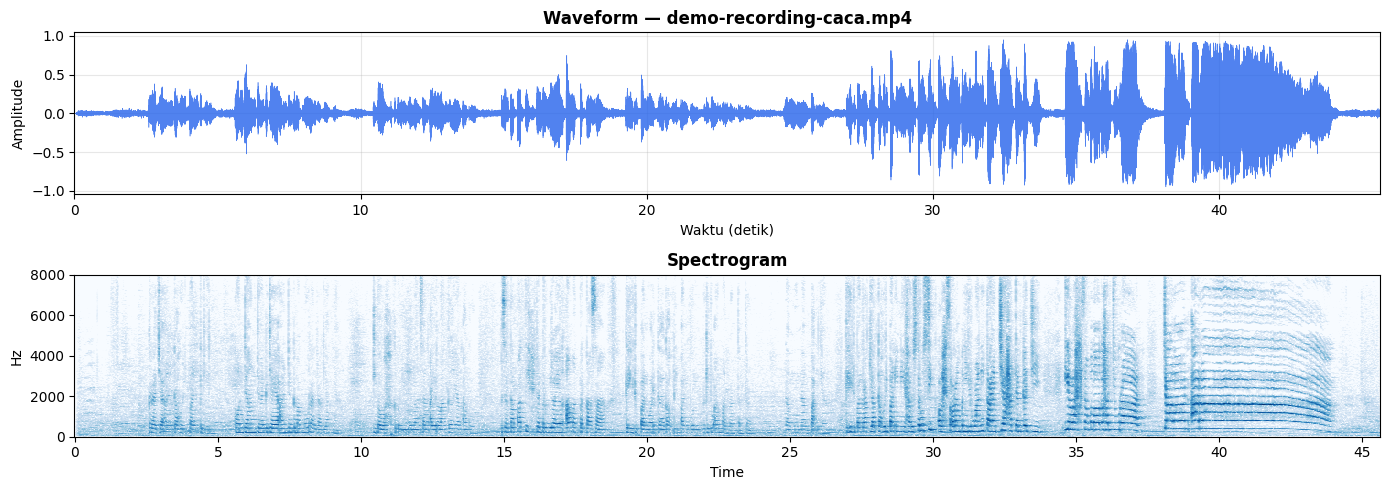

Plot disimpan.


In [10]:
# ── Visualisasi Waveform ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Waveform
time_axis = np.linspace(0, duration_sec, len(audio_array))
axes[0].plot(time_axis, audio_array, color='#2563EB', linewidth=0.4, alpha=0.8)
axes[0].set_title(f'Waveform — {AUDIO_FILE.name}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Waktu (detik)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim(0, duration_sec)
axes[0].grid(True, alpha=0.3)

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_array)), ref=np.max)
librosa.display.specshow(D, sr=SAMPLE_RATE, x_axis='time', y_axis='hz',
                          ax=axes[1], cmap='Blues')
axes[1].set_title('Spectrogram', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 8000)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'waveform_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

## 3. Helper — Evaluasi & Normalisasi

In [11]:
results = {}  # dict untuk menyimpan semua hasil

def evaluate_transcription(model_name: str,
                             hypothesis: str,
                             reference: str,
                             inference_time: float,
                             audio_duration: float) -> dict:
    """
    Hitung WER, CER, RTF, dan estimasi latensi.
    RTF < 1.0 → lebih cepat dari real-time (bagus untuk streaming)
    """
    hyp = normalize_text(hypothesis)
    ref = normalize_text(reference)

    word_error_rate    = wer(ref, hyp)
    char_error_rate    = cer(ref, hyp)
    rtf                = inference_time / audio_duration

    res = {
        'model'            : model_name,
        'wer'              : round(word_error_rate * 100, 2),
        'cer'              : round(char_error_rate  * 100, 2),
        'rtf'              : round(rtf, 4),
        'inference_sec'    : round(inference_time, 2),
        'audio_duration_sec': round(audio_duration, 2),
        'word_count_hyp'   : len(hyp.split()),
        'word_count_ref'   : len(ref.split()),
        'transcription'    : hypothesis,
    }

    print(f'\n{'='*55}')
    print(f'  Model     : {model_name}')
    print(f'{'='*55}')
    print(f'  WER       : {res["wer"]}%')
    print(f'  CER       : {res["cer"]}%')
    print(f'  RTF       : {res["rtf"]} ({"✅ real-time capable" if rtf < 1 else "⚠️ terlalu lambat untuk streaming"})')
    print(f'  Inference : {res["inference_sec"]} detik')
    print(f'  Words     : GT={res["word_count_ref"]} | Hyp={res["word_count_hyp"]}')
    print(f'{'='*55}')
    print(f'\nTranskrip (200 kata pertama):')
    print(' '.join(hypothesis.split()[:200]))

    return res

## 4. Model A — OpenAI Whisper

In [12]:
import whisper

# ── Config: ganti model_size sesuai VRAM ─────────────────────────────────────
# 'tiny'  ~1GB  | 'base' ~1GB  | 'small' ~2GB
# 'medium' ~5GB | 'large-v3' ~10GB
WHISPER_MODEL_SIZE = 'medium'   # ← ganti ke 'large-v3' jika VRAM cukup

print(f'Loading Whisper {WHISPER_MODEL_SIZE}...')
whisper_model = whisper.load_model(WHISPER_MODEL_SIZE, device=DEVICE)
print('Model loaded.')

Loading Whisper medium...


100%|█████████████████████████████████████| 1.42G/1.42G [03:27<00:00, 7.36MiB/s]


Model loaded.


In [15]:
import whisper

WHISPER_MODEL_SIZE = 'medium'

print(f'Loading Whisper {WHISPER_MODEL_SIZE}...')
whisper_model = whisper.load_model(WHISPER_MODEL_SIZE, device=DEVICE)
print('Model loaded.')

print(f'Menjalankan Whisper {WHISPER_MODEL_SIZE}...')
t0 = time.time()

# Kasih audio_array langsung, bukan path file
# Whisper expects float32 numpy array
audio_input = audio_array.astype('float32')

whisper_result = whisper_model.transcribe(
    audio_input,                        # ← numpy array, bukan str(WAV_FILE)
    language='id',
    task='transcribe',
    verbose=False,
    condition_on_previous_text=True,
    fp16=(DEVICE == 'cuda'),
)

whisper_time = time.time() - t0
whisper_text = whisper_result['text'].strip()

with open(OUTPUT_DIR / f'whisper_{WHISPER_MODEL_SIZE}_raw.txt', 'w', encoding='utf-8') as f:
    f.write(whisper_text)

results[f'whisper_{WHISPER_MODEL_SIZE}'] = evaluate_transcription(
    model_name     = f'Whisper {WHISPER_MODEL_SIZE}',
    hypothesis     = whisper_text,
    reference      = ground_truth_raw,
    inference_time = whisper_time,
    audio_duration = duration_sec,
)

Loading Whisper medium...


100%|█████████████████████████████████████| 1.42G/1.42G [03:49<00:00, 6.65MiB/s]


Model loaded.
Menjalankan Whisper medium...


100%|██████████| 4561/4561 [00:27<00:00, 168.17frames/s]


  Model     : Whisper medium
  WER       : 22.45%
  CER       : 10.14%
  RTF       : 0.6037 (✅ real-time capable)
  Inference : 27.53 detik
  Words     : GT=49 | Hyp=53

Transkrip (200 kata pertama):
Kerajaan Kahuripan kediri, kondang dengan kejayaan dan kemakmuran rakyatnya. Dibawah kepemimpinan sang air langga yang agung, beserta patih dan perwira yang amat perkasa, kehidupan warga Kahuripan pun begitu aman dan tenteram. Namun nampaknya kehidupan rakyat Kahuripan ini harus terusik oleh seorang penyihir wanita yang jahat dan keji. Ialah sang pemawak kehancuran, Calon Arang!


In [16]:
# ── Lihat segment-level output Whisper ───────────────────────────────────────
print('Segment-level output (10 segmen pertama):')
print(f'{"Start":>8} {"End":>8}  {"Text"}')
print('─' * 70)
for seg in whisper_result['segments'][:10]:
    print(f'{seg["start"]:>7.1f}s {seg["end"]:>7.1f}s  {seg["text"].strip()}')

Segment-level output (10 segmen pertama):
   Start      End  Text
──────────────────────────────────────────────────────────────────────
    0.0s     9.4s  Kerajaan Kahuripan kediri, kondang dengan kejayaan dan kemakmuran rakyatnya.
    9.4s    18.6s  Dibawah kepemimpinan sang air langga yang agung, beserta patih dan perwira yang amat perkasa,
   18.6s    23.9s  kehidupan warga Kahuripan pun begitu aman dan tenteram.
   24.7s    33.9s  Namun nampaknya kehidupan rakyat Kahuripan ini harus terusik oleh seorang penyihir wanita yang jahat dan keji.
   33.9s    44.3s  Ialah sang pemawak kehancuran, Calon Arang!


## 5. Model B — Wav2Vec 2.0 XLSR-53 Indonesian

In [17]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

W2V_MODEL_ID = 'indonesian-nlp/wav2vec2-large-xlsr-indonesian'

print(f'Loading {W2V_MODEL_ID}...')
w2v_processor = Wav2Vec2Processor.from_pretrained(W2V_MODEL_ID)
w2v_model     = Wav2Vec2ForCTC.from_pretrained(W2V_MODEL_ID).to(DEVICE)
w2v_model.eval()
print('Model loaded.')

Loading indonesian-nlp/wav2vec2-large-xlsr-indonesian...


preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

c:\Users\Aufii\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\configuration_utils.py:312: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


...

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Model loaded.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [18]:
# ── Inference Wav2Vec — Chunk-based (hindari OOM untuk audio panjang) ─────────
CHUNK_SEC    = 30       # detik per chunk
OVERLAP_SEC  = 1        # overlap antar chunk (konteks)
CHUNK_SAMPLES   = CHUNK_SEC   * SAMPLE_RATE
OVERLAP_SAMPLES = OVERLAP_SEC * SAMPLE_RATE

def wav2vec_transcribe_chunked(audio: np.ndarray,
                                processor,
                                model,
                                chunk_samples: int,
                                overlap_samples: int,
                                device: str) -> str:
    """Transkripsi audio panjang dengan sliding window."""
    step     = chunk_samples - overlap_samples
    segments = []
    n        = len(audio)
    starts   = range(0, n, step)
    total    = len(list(starts))

    for i, start in enumerate(range(0, n, step)):
        end   = min(start + chunk_samples, n)
        chunk = audio[start:end]

        if len(chunk) < 1600:   # skip chunk terlalu pendek
            continue

        inputs = processor(
            chunk,
            sampling_rate=SAMPLE_RATE,
            return_tensors='pt',
            padding=True,
        ).input_values.to(device)

        with torch.no_grad():
            logits = model(inputs).logits

        pred_ids = torch.argmax(logits, dim=-1)
        text     = processor.batch_decode(pred_ids)[0].strip()
        segments.append(text)

        if (i + 1) % 5 == 0 or (i + 1) == total:
            print(f'  Chunk {i+1}/{total} selesai')

    return ' '.join(segments)


print('Menjalankan Wav2Vec 2.0 (chunk-based)...')
t0 = time.time()

w2v_text = wav2vec_transcribe_chunked(
    audio          = audio_array,
    processor      = w2v_processor,
    model          = w2v_model,
    chunk_samples  = CHUNK_SAMPLES,
    overlap_samples= OVERLAP_SAMPLES,
    device         = DEVICE,
)

w2v_time = time.time() - t0

# Simpan hasil mentah
with open(OUTPUT_DIR / 'wav2vec2_xlsr_raw.txt', 'w', encoding='utf-8') as f:
    f.write(w2v_text)

# Evaluasi
results['wav2vec2_xlsr'] = evaluate_transcription(
    model_name      = 'Wav2Vec 2.0 XLSR-53 Indonesian',
    hypothesis      = w2v_text,
    reference       = ground_truth_raw,
    inference_time  = w2v_time,
    audio_duration  = duration_sec,
)

Menjalankan Wav2Vec 2.0 (chunk-based)...


model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

  Chunk 2/2 selesai

  Model     : Wav2Vec 2.0 XLSR-53 Indonesian
  WER       : 61.22%
  CER       : 23.48%
  RTF       : 0.2068 (✅ real-time capable)
  Inference : 9.43 detik
  Words     : GT=49 | Hyp=49

Transkrip (200 kata pertama):
kerajaan tahuripan pediri kondang dengan kejayaain dan kemakmuran rakyaknyadibawah kebegininan sayata airlang gelayang aku besartan patih dan berwira yang amat perkasa kehidupan luarga kahuri panpun begitu ampantantantra namu nampaknya kehidupan rakyat kahuripan ini harus terusik harus terusik oleh seorang pengihirwanita yang cahat dan gaji ialah sampebawu tahan curan cawananaan


## 6. Perbandingan & Visualisasi

In [19]:
import pandas as pd

# ── Summary Table ─────────────────────────────────────────────────────────────
summary_cols = ['model', 'wer', 'cer', 'rtf', 'inference_sec', 'audio_duration_sec']
df = pd.DataFrame(results.values())[summary_cols]
df.columns = ['Model', 'WER (%)', 'CER (%)', 'RTF', 'Inference (s)', 'Audio (s)']
df = df.sort_values('WER (%)')

print('\n📊 SUMMARY HASIL EVALUASI BASELINE')
print('─' * 70)
print(df.to_string(index=False))
print('─' * 70)
print('RTF < 1.0 → potensi real-time streaming')
print('WER target: < 15% (umum), < 20% (terminologi teknis)')


📊 SUMMARY HASIL EVALUASI BASELINE
──────────────────────────────────────────────────────────────────────
                         Model  WER (%)  CER (%)    RTF  Inference (s)  Audio (s)
                Whisper medium    22.45    10.14 0.6037          27.53      45.61
Wav2Vec 2.0 XLSR-53 Indonesian    61.22    23.48 0.2068           9.43      45.61
──────────────────────────────────────────────────────────────────────
RTF < 1.0 → potensi real-time streaming
WER target: < 15% (umum), < 20% (terminologi teknis)


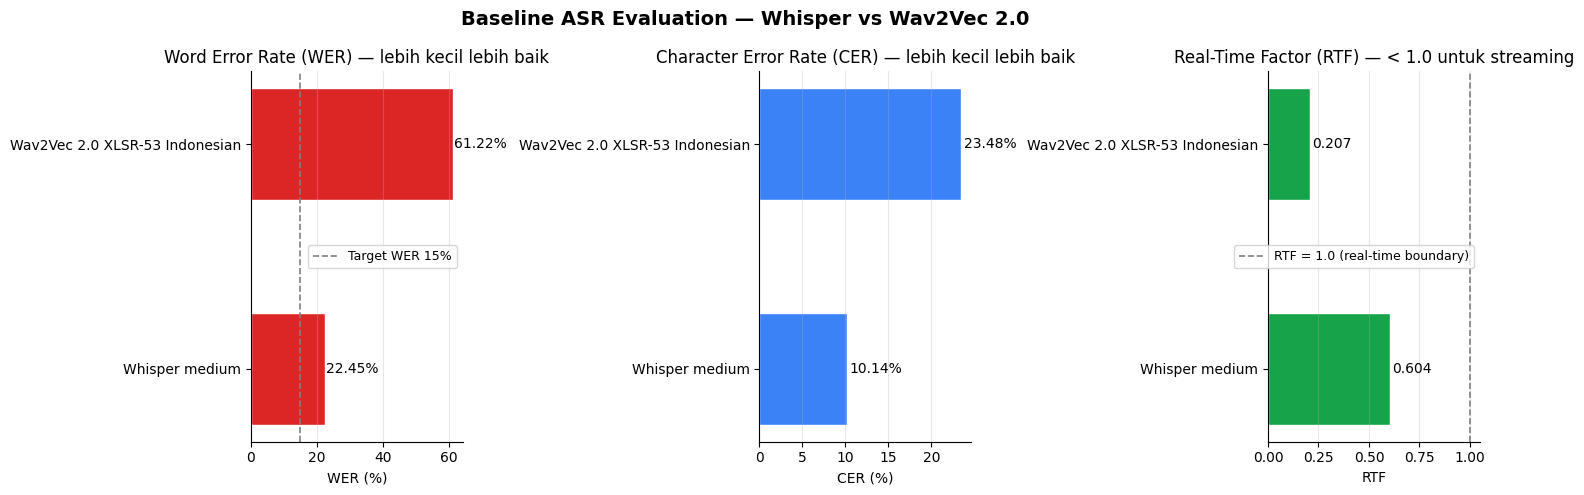

Plot disimpan.


In [20]:
# ── Visualisasi: WER, CER, RTF ────────────────────────────────────────────────
models = [r['model'] for r in results.values()]
wers   = [r['wer']   for r in results.values()]
cers   = [r['cer']   for r in results.values()]
rtfs   = [r['rtf']   for r in results.values()]

colors_wer = ['#16A34A' if w < 15 else '#DC2626' for w in wers]
colors_rtf = ['#16A34A' if r < 1.0 else '#F59E0B' for r in rtfs]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Baseline ASR Evaluation — Whisper vs Wav2Vec 2.0', fontsize=14, fontweight='bold')

# WER
bars = axes[0].barh(models, wers, color=colors_wer, edgecolor='white', height=0.5)
axes[0].axvline(x=15, color='gray', linestyle='--', linewidth=1.2, label='Target WER 15%')
axes[0].set_title('Word Error Rate (WER) — lebih kecil lebih baik')
axes[0].set_xlabel('WER (%)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, wers):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                  f'{val}%', va='center', fontsize=10)

# CER
bars2 = axes[1].barh(models, cers, color='#3B82F6', edgecolor='white', height=0.5)
axes[1].set_title('Character Error Rate (CER) — lebih kecil lebih baik')
axes[1].set_xlabel('CER (%)')
for bar, val in zip(bars2, cers):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                  f'{val}%', va='center', fontsize=10)

# RTF
bars3 = axes[2].barh(models, rtfs, color=colors_rtf, edgecolor='white', height=0.5)
axes[2].axvline(x=1.0, color='gray', linestyle='--', linewidth=1.2, label='RTF = 1.0 (real-time boundary)')
axes[2].set_title('Real-Time Factor (RTF) — < 1.0 untuk streaming')
axes[2].set_xlabel('RTF')
axes[2].legend(fontsize=9)
for bar, val in zip(bars3, rtfs):
    axes[2].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{val:.3f}', va='center', fontsize=10)

for ax in axes:
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan.')

In [ ]:
# ── Error Analysis: WER per Kategori ─────────────────────────────────────────
# Identifikasi kata teknis yang salah dari hasil Whisper
import re
from collections import Counter

# Kata-kata teknis ilmu komputer yang relevan
TECH_TERMS = [
    'algoritma', 'fungsi', 'variabel', 'array', 'loop', 'rekursi',
    'pointer', 'stack', 'queue', 'tree', 'graph', 'database', 'server',
    'client', 'api', 'endpoint', 'framework', 'library', 'class', 'object',
    'method', 'interface', 'inheritance', 'polymorphism', 'abstraksi',
    'kompilasi', 'debugging', 'repository', 'commit', 'branch', 'merge',
]

def count_tech_term_errors(hypothesis: str, reference: str, tech_terms: list) -> dict:
    hyp_words = set(normalize_text(hypothesis).split())
    ref_words = set(normalize_text(reference).split())
    
    tech_in_ref    = [t for t in tech_terms if t in ref_words]
    tech_in_hyp    = [t for t in tech_terms if t in hyp_words]
    tech_missed    = [t for t in tech_in_ref if t not in hyp_words]
    tech_added     = [t for t in tech_in_hyp if t not in ref_words]
    
    return {
        'tech_terms_in_gt'     : tech_in_ref,
        'tech_terms_in_hyp'    : tech_in_hyp,
        'tech_terms_missed'    : tech_missed,
        'tech_terms_hallucinated': tech_added,
    }

print('\n🔍 Error Analysis — Kata Teknis\n')
for key, res in results.items():
    analysis = count_tech_term_errors(res['transcription'], ground_truth_raw, TECH_TERMS)
    print(f'► {res["model"]}')
    print(f'  Kata teknis di GT      : {analysis["tech_terms_in_gt"]}')
    print(f'  Kata teknis benar     : {[t for t in analysis["tech_terms_in_hyp"] if t in analysis["tech_terms_in_gt"]]}')
    print(f'  Kata teknis terlewat  : {analysis["tech_terms_missed"]}')
    print(f'  Halusinasi teknis     : {analysis["tech_terms_hallucinated"]}')
    print()

: 

: 

: 

: 

: 

## 7. Simpan Hasil & Kesimpulan

In [ ]:
# ── Simpan ke JSON ────────────────────────────────────────────────────────────
output_json = OUTPUT_DIR / 'baseline_results.json'
with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f'Hasil disimpan ke: {output_json}')

# ── Kesimpulan Otomatis ───────────────────────────────────────────────────────
best_wer_key = min(results, key=lambda k: results[k]['wer'])
best_rtf_key = min(results, key=lambda k: results[k]['rtf'])
best_wer_res = results[best_wer_key]
best_rtf_res = results[best_rtf_key]

print()
print('━' * 60)
print('📋 KESIMPULAN BASELINE EVALUATION')
print('━' * 60)
print(f'✅ Akurasi terbaik (WER terendah) : {best_wer_res["model"]} — WER {best_wer_res["wer"]}%')
print(f'⚡ Kecepatan terbaik (RTF terendah): {best_rtf_res["model"]} — RTF {best_rtf_res["rtf"]}')
print()
print('Rekomendasi next step:')
print('  1. Fine-tune Whisper medium/large-v3 dengan dataset Filkom UB')
print('  2. Fine-tune Wav2Vec 2.0 XLSR-53 + IndoBERT punctuation')
print('  3. Tambahkan custom vocabulary teknis ilmu komputer')
print('  4. Target WER < 15% setelah fine-tuning')
print('━' * 60)

: 

: 

: 

: 

: 